In [1]:
from IPython import get_ipython
get_ipython().run_line_magic("matplotlib", "inline") 
import matplotlib.pyplot as plt
import matplotlib
print(matplotlib.get_backend())  

inline


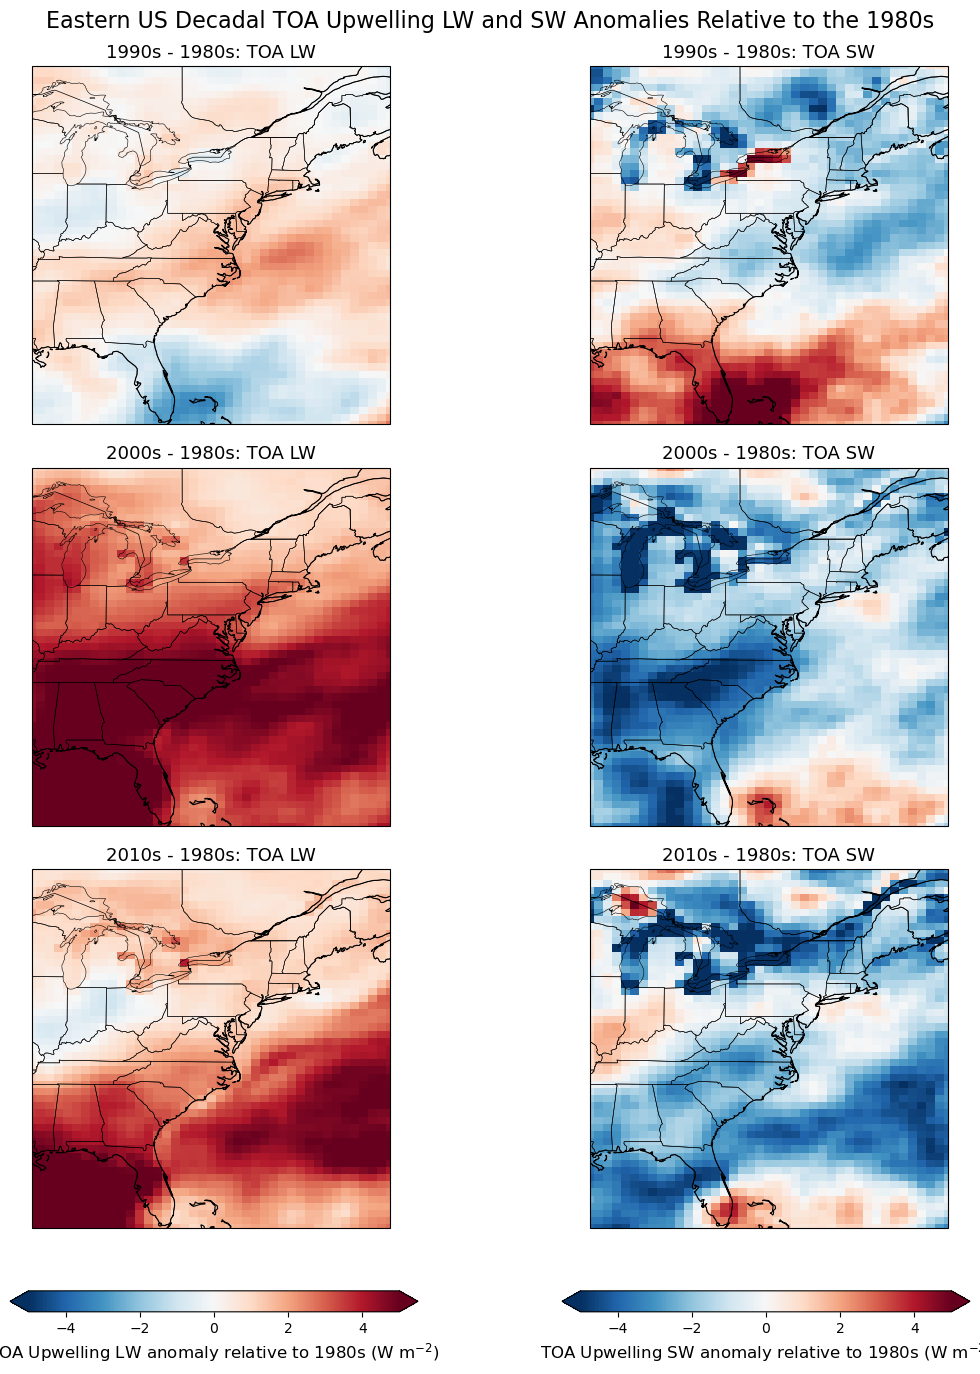

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# File path
# -----------------------------
nc_file = "/scratch/sjacker2/project_data/merra2_rad_downloads/merra2_toa_upwelling_lw_sw_combined.nc"

# -----------------------------
# Open dataset
# -----------------------------
ds = xr.open_dataset(nc_file)

# -----------------------------
# Keep only 1980–2019 so each decade is complete
# -----------------------------
ds = ds.sel(time=slice("1980-01-01", "2019-12-31"))

# -----------------------------
# Compute annual means first
# -----------------------------
sw_annual = ds["TOA_SW_UP"].groupby("time.year").mean("time")
lw_annual = ds["TOA_LW_UP"].groupby("time.year").mean("time")

# -----------------------------
# Compute decadal means
# -----------------------------
sw_1980s = sw_annual.sel(year=slice(1980, 1989)).mean("year")
sw_1990s = sw_annual.sel(year=slice(1990, 1999)).mean("year")
sw_2000s = sw_annual.sel(year=slice(2000, 2009)).mean("year")
sw_2010s = sw_annual.sel(year=slice(2010, 2019)).mean("year")

lw_1980s = lw_annual.sel(year=slice(1980, 1989)).mean("year")
lw_1990s = lw_annual.sel(year=slice(1990, 1999)).mean("year")
lw_2000s = lw_annual.sel(year=slice(2000, 2009)).mean("year")
lw_2010s = lw_annual.sel(year=slice(2010, 2019)).mean("year")

# -----------------------------
# Compute anomalies relative to 1980s
# -----------------------------
sw_1990s_minus_1980s = sw_1990s - sw_1980s
sw_2000s_minus_1980s = sw_2000s - sw_1980s
sw_2010s_minus_1980s = sw_2010s - sw_1980s

lw_1990s_minus_1980s = lw_1990s - lw_1980s
lw_2000s_minus_1980s = lw_2000s - lw_1980s
lw_2010s_minus_1980s = lw_2010s - lw_1980s

# -----------------------------
# Fixed color scale limits
# -----------------------------
vmin = -5
vmax = 5

# -----------------------------
# Set up figure
# -----------------------------
proj = ccrs.PlateCarree()
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12, 14),
    subplot_kw={"projection": proj}
)

# Left column = LW, Right column = SW
lw_anoms = [
    lw_1990s_minus_1980s,
    lw_2000s_minus_1980s,
    lw_2010s_minus_1980s
]
sw_anoms = [
    sw_1990s_minus_1980s,
    sw_2000s_minus_1980s,
    sw_2010s_minus_1980s
]
row_titles = [
    "1990s - 1980s",
    "2000s - 1980s",
    "2010s - 1980s"
]

# -----------------------------
# Plot maps
# -----------------------------
for i in range(3):
    # LW panel (left)
    ax = axes[i, 0]
    pcm_lw = ax.pcolormesh(
        ds["lon"],
        ds["lat"],
        lw_anoms[i],
        transform=proj,
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto"
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    ax.set_extent(
        [
            float(ds["lon"].min()),
            float(ds["lon"].max()),
            float(ds["lat"].min()),
            float(ds["lat"].max())
        ],
        crs=proj
    )
    ax.set_title(f"{row_titles[i]}: TOA LW", fontsize=13)

    # SW panel (right)
    ax = axes[i, 1]
    pcm_sw = ax.pcolormesh(
        ds["lon"],
        ds["lat"],
        sw_anoms[i],
        transform=proj,
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        shading="auto"
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    ax.set_extent(
        [
            float(ds["lon"].min()),
            float(ds["lon"].max()),
            float(ds["lat"].min()),
            float(ds["lat"].max())
        ],
        crs=proj
    )
    ax.set_title(f"{row_titles[i]}: TOA SW", fontsize=13)

# -----------------------------
# Layout and bottom colorbars
# -----------------------------
plt.subplots_adjust(
    top=0.95,
    bottom=0.12,
    left=0.06,
    right=0.94,
    hspace=0.12,
    wspace=0.12
)

cax_lw = fig.add_axes([0.10, 0.06, 0.34, 0.015])
cax_sw = fig.add_axes([0.56, 0.06, 0.34, 0.015])

cbar_lw = fig.colorbar(
    pcm_lw,
    cax=cax_lw,
    orientation="horizontal",
    extend="both"
)
cbar_lw.set_label("TOA Upwelling LW anomaly relative to 1980s (W m$^{-2}$)", fontsize=12)

cbar_sw = fig.colorbar(
    pcm_sw,
    cax=cax_sw,
    orientation="horizontal",
    extend="both"
)
cbar_sw.set_label("TOA Upwelling SW anomaly relative to 1980s (W m$^{-2}$)", fontsize=12)

plt.suptitle(
    "Eastern US Decadal TOA Upwelling LW and SW Anomalies Relative to the 1980s",
    fontsize=16,
    y=0.99
)
plt.show()

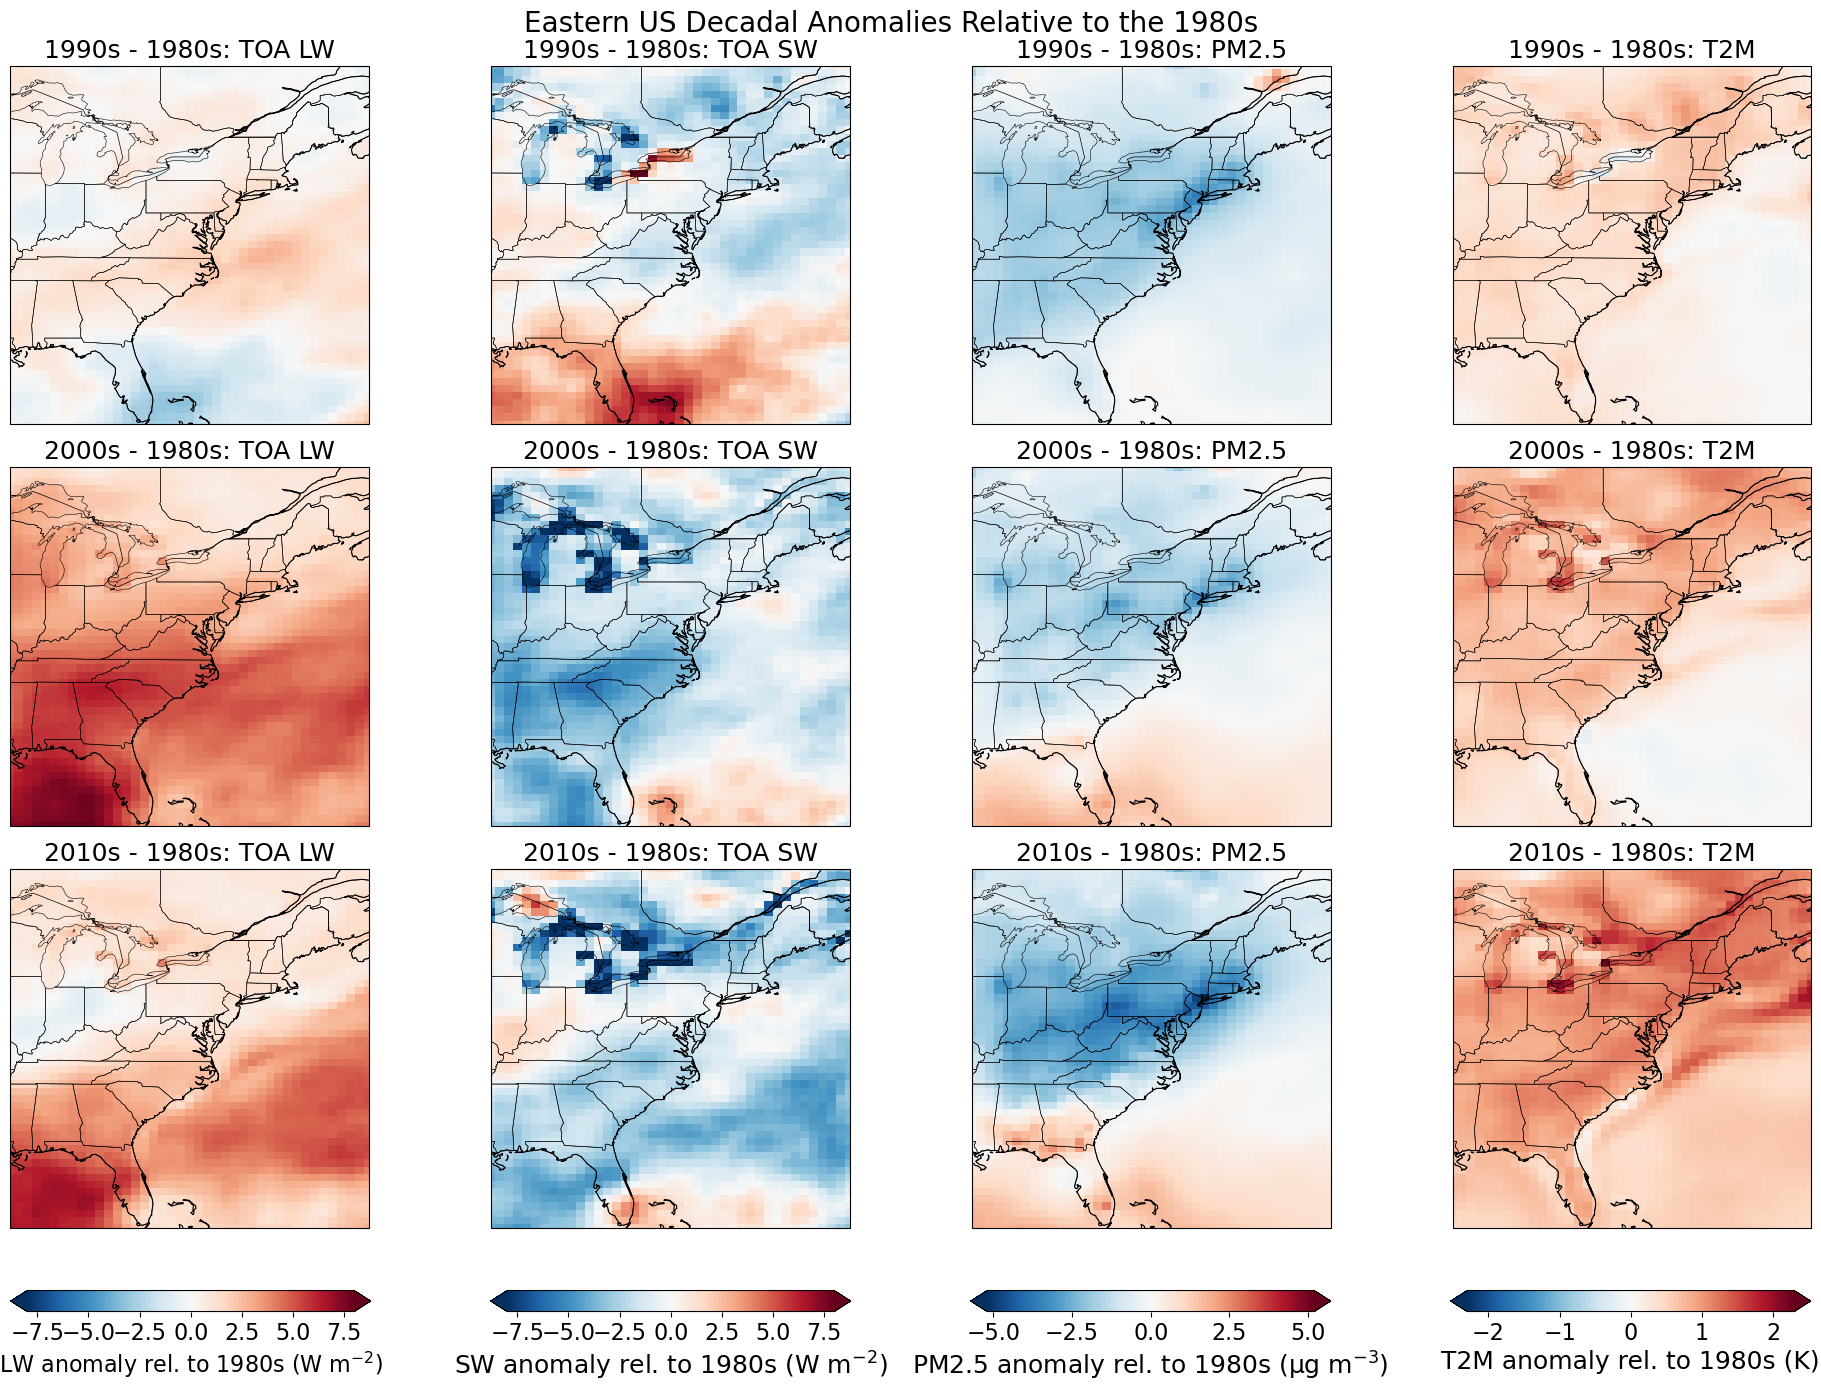

In [15]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# -----------------------------
# File paths
# -----------------------------
flux_file = "/scratch/sjacker2/project_data/merra2_rad_downloads/merra2_toa_upwelling_lw_sw_combined.nc"
pm25_t2m_file = "/scratch/sjacker2/project_data/merra2_pm25_t2m_eastern_us_monthly_fields_DRY.nc"

# -----------------------------
# Open datasets
# -----------------------------
ds_flux = xr.open_dataset(flux_file)
ds_pm = xr.open_dataset(pm25_t2m_file)

# -----------------------------
# Keep only 1980–2019 so each decade is complete
# -----------------------------
ds_flux = ds_flux.sel(time=slice("1980-01-01", "2019-12-31"))
ds_pm = ds_pm.sel(time=slice("1980-01-01", "2019-12-31"))

# -----------------------------
# Compute annual means first
# -----------------------------
sw_annual = ds_flux["TOA_SW_UP"].groupby("time.year").mean("time")
lw_annual = ds_flux["TOA_LW_UP"].groupby("time.year").mean("time")
pm25_annual = ds_pm["PM25_dry"].groupby("time.year").mean("time")
t2m_annual = ds_pm["T2M"].groupby("time.year").mean("time")

# -----------------------------
# Compute decadal means
# -----------------------------
def decade_mean(da, start_year, end_year):
    return da.sel(year=slice(start_year, end_year)).mean("year")

sw_1980s = decade_mean(sw_annual, 1980, 1989)
sw_1990s = decade_mean(sw_annual, 1990, 1999)
sw_2000s = decade_mean(sw_annual, 2000, 2009)
sw_2010s = decade_mean(sw_annual, 2010, 2019)

lw_1980s = decade_mean(lw_annual, 1980, 1989)
lw_1990s = decade_mean(lw_annual, 1990, 1999)
lw_2000s = decade_mean(lw_annual, 2000, 2009)
lw_2010s = decade_mean(lw_annual, 2010, 2019)

pm25_1980s = decade_mean(pm25_annual, 1980, 1989)
pm25_1990s = decade_mean(pm25_annual, 1990, 1999)
pm25_2000s = decade_mean(pm25_annual, 2000, 2009)
pm25_2010s = decade_mean(pm25_annual, 2010, 2019)

t2m_1980s = decade_mean(t2m_annual, 1980, 1989)
t2m_1990s = decade_mean(t2m_annual, 1990, 1999)
t2m_2000s = decade_mean(t2m_annual, 2000, 2009)
t2m_2010s = decade_mean(t2m_annual, 2010, 2019)

# -----------------------------
# Compute anomalies relative to 1980s
# -----------------------------
sw_anoms = [
    sw_1990s - sw_1980s,
    sw_2000s - sw_1980s,
    sw_2010s - sw_1980s,
]

lw_anoms = [
    lw_1990s - lw_1980s,
    lw_2000s - lw_1980s,
    lw_2010s - lw_1980s,
]

pm25_anoms = [
    pm25_1990s - pm25_1980s,
    pm25_2000s - pm25_1980s,
    pm25_2010s - pm25_1980s,
]

t2m_anoms = [
    t2m_1990s - t2m_1980s,
    t2m_2000s - t2m_1980s,
    t2m_2010s - t2m_1980s,
]

# -----------------------------
# Color limits
# -----------------------------
# Fluxes fixed to ±5 W m^-2 as requested earlier
flux_vmin = -8
flux_vmax =8

# PM2.5 and T2M: symmetric ranges based on anomaly magnitude
pm25_absmax = max(np.nanmax(np.abs(a.values)) for a in pm25_anoms)
t2m_absmax = max(np.nanmax(np.abs(a.values)) for a in t2m_anoms)

pm25_vmax = np.ceil(pm25_absmax * 10) / 10
pm25_vmin = -pm25_vmax

t2m_vmax = np.ceil(t2m_absmax * 10) / 10
t2m_vmin = -t2m_vmax

# -----------------------------
# Plot setup
# -----------------------------
row_titles = ["1990s - 1980s", "2000s - 1980s", "2010s - 1980s"]
proj = ccrs.PlateCarree()

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(20, 14),
    subplot_kw={"projection": proj}
)

lon_flux = ds_flux["lon"]
lat_flux = ds_flux["lat"]
lon_pm = ds_pm["lon"]
lat_pm = ds_pm["lat"]

extent_flux = [
    float(lon_flux.min()),
    float(lon_flux.max()),
    float(lat_flux.min()),
    float(lat_flux.max())
]
extent_pm = [
    float(lon_pm.min()),
    float(lon_pm.max()),
    float(lat_pm.min()),
    float(lat_pm.max())
]

# -----------------------------
# Make plots
# -----------------------------
for i in range(3):
    # Column 1: TOA LW
    ax = axes[i, 0]
    pcm_lw = ax.pcolormesh(
        lon_flux, lat_flux, lw_anoms[i],
        transform=proj,
        cmap="RdBu_r",
        vmin=flux_vmin,
        vmax=flux_vmax,
        shading="auto"
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    ax.set_extent(extent_flux, crs=proj)
    ax.set_title(f"{row_titles[i]}: TOA LW", fontsize=18)

    # Column 2: TOA SW
    ax = axes[i, 1]
    pcm_sw = ax.pcolormesh(
        lon_flux, lat_flux, sw_anoms[i],
        transform=proj,
        cmap="RdBu_r",
        vmin=flux_vmin,
        vmax=flux_vmax,
        shading="auto"
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    ax.set_extent(extent_flux, crs=proj)
    ax.set_title(f"{row_titles[i]}: TOA SW", fontsize=18)

    # Column 3: PM2.5
    ax = axes[i, 2]
    pcm_pm25 = ax.pcolormesh(
        lon_pm, lat_pm, pm25_anoms[i],
        transform=proj,
        cmap="RdBu_r",
        vmin=pm25_vmin,
        vmax=pm25_vmax,
        shading="auto"
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    ax.set_extent(extent_pm, crs=proj)
    ax.set_title(f"{row_titles[i]}: PM2.5", fontsize=18)

    # Column 4: T2M
    ax = axes[i, 3]
    pcm_t2m = ax.pcolormesh(
        lon_pm, lat_pm, t2m_anoms[i],
        transform=proj,
        cmap="RdBu_r",
        vmin=t2m_vmin,
        vmax=t2m_vmax,
        shading="auto"
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.STATES, linewidth=0.4)
    ax.set_extent(extent_pm, crs=proj)
    ax.set_title(f"{row_titles[i]}: T2M", fontsize=18)

# -----------------------------
# Adjust layout
# -----------------------------
plt.subplots_adjust(
    top=0.95,
    bottom=0.12,
    left=0.04,
    right=0.98,
    hspace=0.12,
    wspace=0.10
)

# -----------------------------
# Add bottom colorbars
# -----------------------------
cax_lw   = fig.add_axes([0.06, 0.06, 0.18, 0.015])
cax_sw   = fig.add_axes([0.30, 0.06, 0.18, 0.015])
cax_pm25 = fig.add_axes([0.54, 0.06, 0.18, 0.015])
cax_t2m  = fig.add_axes([0.78, 0.06, 0.18, 0.015])

flux_ticks = [-7.5, -5, -2.5, 0, 2.5, 5, 7.5]

cbar_lw = fig.colorbar(
    pcm_lw,
    cax=cax_lw,
    orientation="horizontal",
    extend="both",
    ticks=flux_ticks
)
cbar_lw.set_label("LW anomaly rel. to 1980s (W m$^{-2}$)", fontsize=16)
cbar_lw.ax.tick_params(labelsize=16)

cbar_sw = fig.colorbar(
    pcm_sw,
    cax=cax_sw,
    orientation="horizontal",
    extend="both",
    ticks=flux_ticks
)
cbar_sw.set_label("SW anomaly rel. to 1980s (W m$^{-2}$)", fontsize=18)
cbar_sw.ax.tick_params(labelsize=16)

pm25_ticks = [-5, -2.5, 0, 2.5, 5]

cbar_pm25 = fig.colorbar(pcm_pm25, cax=cax_pm25, orientation="horizontal", extend="both", ticks=pm25_ticks)
cbar_pm25.set_label("PM2.5 anomaly rel. to 1980s (µg m$^{-3}$)", fontsize=18)
cbar_pm25.ax.tick_params(labelsize=16)

t2m_ticks = [-2, -1, 0, 1, 2]

cbar_t2m = fig.colorbar(pcm_t2m, cax=cax_t2m, orientation="horizontal", extend="both", ticks=t2m_ticks)
cbar_t2m.set_label("T2M anomaly rel. to 1980s (K)", fontsize=18)
cbar_t2m.ax.tick_params(labelsize=16)

plt.suptitle(
    "Eastern US Decadal Anomalies Relative to the 1980s",
    fontsize=20,
    y=0.99
)

plt.show()